## 1. Configuración inicial
Se importan las librerías necesarias para el análisis: pandas y numpy para manejo de datos, matplotlib y seaborn para visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


## 2. Carga del dataset
Se carga el archivo `insurance.csv` (Medical Cost Personal Dataset) y se muestra una vista previa de los primeros registros.

In [2]:
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Verificación de tipos de datos
Se revisa la estructura del dataset: número de registros, columnas disponibles y el tipo de dato de cada una (numérico o categórico).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## 4. Verificación de valores nulos
Se confirma si existen valores faltantes en alguna de las 7 variables del dataset.

In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 5. Verificación y eliminación de duplicados
Se identifica si existen registros duplicados en el dataset. Se detectó 1 registro duplicado, el cual fue eliminado para evitar sesgos en el análisis (de 1338 a 1337 registros).

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates()
df.shape

(1337, 7)

## 6. Estadísticas descriptivas
Se obtienen medidas estadísticas generales (media, desviación estándar, mínimos, máximos, cuartiles) de las variables numéricas, y frecuencias de las variables categóricas.

In [7]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


## 7. Preparación de variables para análisis de correlación
Dado que las variables `sex`, `smoker` y `region` son categóricas (texto), es necesario convertirlas a formato numérico para poder calcular correlaciones. Se crea una copia del dataset con estas transformaciones, dejando el dataset original intacto.

In [8]:
df_numerico = df.copy()
df_numerico["sex"] = df_numerico["sex"].map({"male": 0, "female": 1})
df_numerico["smoker"] = df_numerico["smoker"].map({"no": 0, "yes": 1})
df_numerico = pd.get_dummies(df_numerico, columns=["region"], drop_first=True)

df_numerico.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


## 8. Matriz de correlación
Se calcula la correlación entre todas las variables numéricas del dataset y se visualiza mediante un mapa de calor (heatmap) usando seaborn, tal como fue recomendado por el profesor. Esto permite identificar qué variables tienen mayor relación con los cargos médicos (`charges`), sirviendo como base para el análisis de correlación e interpretación que realizará el equipo en los siguientes días.

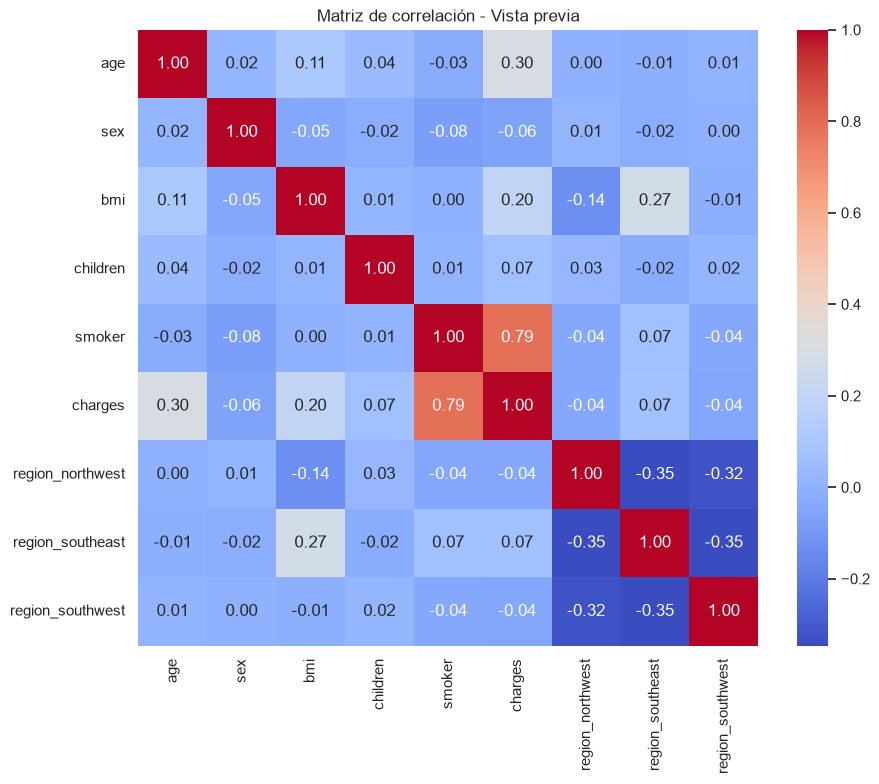

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_numerico.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación - Vista previa")
plt.savefig("../reports/figures/correlacion_preview.png")
plt.show()